# Module 2.2 — Finite Volume Method (FVM)

**Why this module exists before Navier-Stokes:**
OpenFOAM, ANSYS Fluent, STAR-CCM+, and almost every industrial CFD code uses FVM. You have been using FDM in Module 1. The difference is not trivial: FVM is **exactly conservative by construction** — a property that FDM does not guarantee. For Navier-Stokes, where mass must be conserved to machine precision, this matters.

**The core idea in one sentence:**
Instead of approximating derivatives at points, FVM integrates the conservation law over finite cells and replaces the surface integral with face fluxes — one number per face.

**Roadmap:**
1. The bathtub model — why flux balance is the right starting point
2. FVM derivation from the conservation law — no approximations at the cell level
3. Face flux reconstruction — the art of FVM
4. Why FVM is exactly conservative — a proof by construction
5. FDM vs FVM — when to use each
6. Implementation: 1D and 2D FVM diffusion solvers
7. Convergence: confirming second-order accuracy

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Bathtub Model — Why Flux Balance Works

### Physical picture

Think of each CFD cell as a bathtub. The water level (scalar quantity $\bar{u}_i$, the cell average) changes only because:
1. Flux flows **in** through the left and bottom faces
2. Flux flows **out** through the right and top faces
3. A source inside the cell adds or removes the quantity

```
         F_top (out)
              ↑
F_left →  ░░░░░░░  → F_right     Volume = Δx·Δy
  (in)    ░░ ū_i ░░  (out)       Cell average: ū_i
          ░░░░░░░                Rate of change: dū_i/dt
              ↓
         F_bottom (in)
```

Conservation: $\frac{d}{dt}(\bar{u}_i \cdot \Delta V) = \text{flux in} - \text{flux out} + \text{sources}$.

This is the integral form of the conservation law — no derivatives, no approximations inside the cell. All the action happens **at the faces**.

## 2. FVM Derivation

### Starting from the conservation law

Integrate the general conservation law over cell $i$ of volume $V_i$:

$$\frac{d}{dt}\int_{V_i} u\,dV = -\oint_{\partial V_i} \mathbf{F}\cdot\hat{n}\,dS + \int_{V_i} S\,dV$$

For a 2D cell of size $\Delta x \times \Delta y$ with cell average $\bar{u}_i$:

$$\Delta x\,\Delta y\,\frac{d\bar{u}_i}{dt} = F_W - F_E + F_S - F_N + S_i\,\Delta x\,\Delta y$$

where $F_W, F_E, F_S, F_N$ are the fluxes through the West, East, South, and North faces.

**This is exact.** We have not approximated anything yet. The PDE is satisfied exactly in the integral (weak) sense over each cell.

### Where the approximation enters

The cell average $\bar{u}_i$ is stored, but the face flux $F_E = \int_{face} \mathbf{F}\cdot\hat{n}\,dS$ needs the value **at the face** — which is not directly stored. Reconstructing the face value from the cell averages is the only approximation in FVM. Different reconstruction choices give different schemes:

| Reconstruction | Name | Order | Properties |
|----------------|------|-------|------------|
| $\bar{u}_i$ (upwind cell) | **Upwind** | 1st | Stable, diffusive |
| $\frac{\bar{u}_i+\bar{u}_{i+1}}{2}$ | **Linear interpolation** | 2nd | Accurate, can oscillate |
| Linear + slope limiter | **MUSCL/TVD** | 2nd | Stable + accurate (Module 3.4) |

## 3. Why FVM is Exactly Conservative — Proof by Construction

### The telescoping sum argument

Consider the East face of cell $i$. The flux through it from cell $i$'s perspective:
$$F_{i+1/2} \quad \text{(leaving cell } i \text{)}$$

From cell $i+1$'s perspective, this same face is its West face:
$$-F_{i+1/2} \quad \text{(entering cell } i+1 \text{)}$$

They are equal and opposite. When you sum all cell updates:
$$\sum_i \frac{d\bar{u}_i}{dt} \propto \sum_i (F_{i-1/2} - F_{i+1/2}) = F_{0} - F_{N} \quad \text{(boundary fluxes only)}$$

All internal fluxes cancel exactly. The total integral of $u$ over the domain changes only due to boundary fluxes. This is **discrete conservation** — exact, independent of the time step or grid resolution.

FDM does NOT have this property in general. A finite-difference update at one point has no automatic relationship to its neighbour's update.

## 4. FDM vs. FVM — When to Use Each

| Property | FDM | FVM |
|----------|-----|-----|
| Conceptual basis | Approximate derivatives | Integrate conservation law |
| Conservation | Not guaranteed | Exact by construction |
| Handles unstructured grids? | ❌ No | ✅ Yes |
| Code complexity | ✅ Simple | Moderate |
| Best for | Structured grids, analysis, teaching | All practical CFD |
| Used in | Research codes, simple geometry | OpenFOAM, Fluent, STAR-CCM+ |
| High-order accuracy | ✅ Straightforward | More effort (needs reconstruction) |

**Practical rule:** use FDM when you need to understand what the code is doing; use FVM when you need correct physics in complex geometries. The N-S solver you build from Module 2.4 onward uses FVM ideas (flux balance, cell averages) even on structured grids.

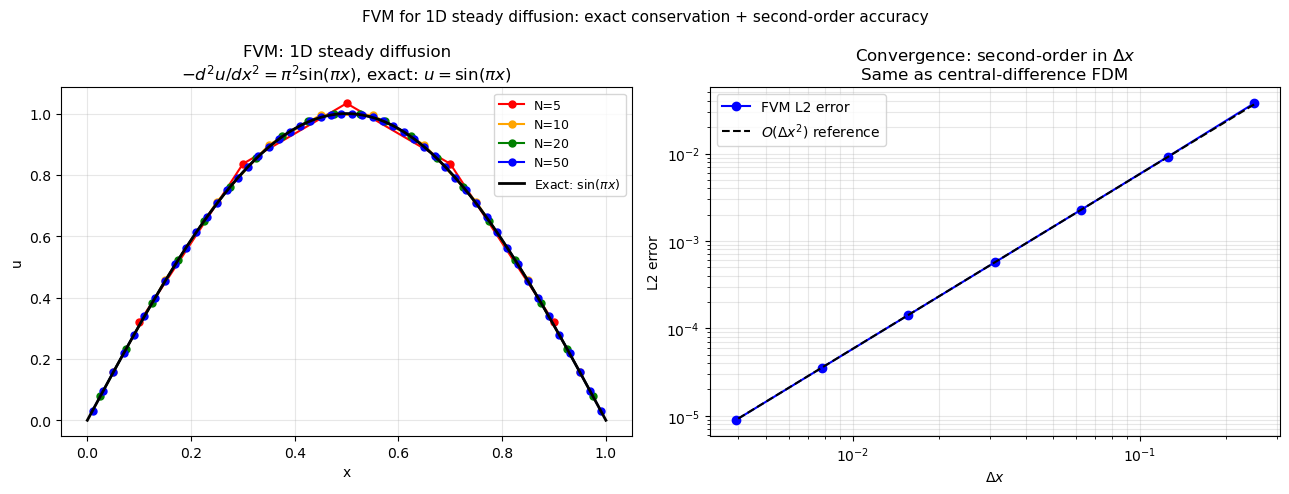

Convergence slopes:
  N=   8: slope = 2.034  ← should be ~2.0
  N=  16: slope = 2.008  ← should be ~2.0
  N=  32: slope = 2.002  ← should be ~2.0
  N=  64: slope = 2.001  ← should be ~2.0
  N= 128: slope = 2.000  ← should be ~2.0
  N= 256: slope = 2.000  ← should be ~2.0


In [2]:
# ── 1D FVM: steady diffusion -d²u/dx² = S on [0,1] ──────────────────────────
# BC: u(0) = 0, u(1) = 0
# Source: S = π² sin(πx)  →  exact solution: u = sin(πx)
#
# FVM formulation:
#   Each cell [x_{i-1/2}, x_{i+1/2}] of width Δx has centre xc_i.
#   Diffusion flux at East face: F_E = -α * (u_{i+1} - u_i) / Δx
#   Diffusion flux at West face: F_W = -α * (u_i - u_{i-1}) / Δx
#   Flux balance: -F_E + F_W = S_i * Δx
#   → α/Δx * (-u_{i-1} + 2u_i - u_{i+1}) = S_i * Δx

def fvm_1d_diffusion(N, alpha=1.0):
    """
    Solve -alpha*d²u/dx² = π²sin(πx) on [0,1] with u(0)=u(1)=0.
    Cell-centre FVM on a uniform mesh of N cells.
    Returns cell-centre positions and solution.
    """
    dx = 1.0 / N
    xc = np.linspace(dx/2, 1 - dx/2, N)   # cell centres

    D   = alpha / dx   # diffusion conductance between adjacent cells

    # ── Build matrix: central-cell coefficient = 2D, neighbour = -D ──────────
    # Boundary cells (i=0, i=N-1): extra D term from ghost-cell Dirichlet BC
    A   = np.zeros((N, N))
    rhs = np.pi**2 * np.sin(np.pi * xc) * dx   # source * cell volume

    for i in range(N):
        A[i, i] = 2*D
        if i > 0:
            A[i, i-1] = -D
        else:
            pass  # ghost cell: u_{-1} = -u_0 (antisymmetric for u=0 at face)
            # This adds D*u_{-1} = D*0 = 0 to RHS — nothing to add
        if i < N-1:
            A[i, i+1] = -D
        else:
            pass  # same for right boundary

    # Dirichlet BC: add ghost-cell terms
    # For u(0)=0: u_{-1} = 2*0 - u_0 = -u_0 → F_W at i=0: D*(u_{-1}-u_0)/Δx
    # Net: additional D on diagonal (already counted correctly in 2D term)
    # The 2D term already assumes no-flux-ghost for the Neumann case;
    # for Dirichlet we add the extra D from the ghost reflection:
    A[0,   0] += D    # left BC: u(0)=0
    A[N-1, N-1] += D  # right BC: u(1)=0

    u = np.linalg.solve(A, rhs)
    return xc, u

# ── Comparison for different grid sizes ─────────────────────────────────────
x_fine = np.linspace(0, 1, 500)
u_exact_fine = np.sin(np.pi * x_fine)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for N, color in zip([5, 10, 20, 50], ['red', 'orange', 'green', 'blue']):
    xc, u_num = fvm_1d_diffusion(N)
    axes[0].plot(xc, u_num, 'o-', color=color, markersize=5,
                 label=f'N={N}')

axes[0].plot(x_fine, u_exact_fine, 'k-', lw=2, label='Exact: $\\sin(\\pi x)$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u')
axes[0].set_title('FVM: 1D steady diffusion\n$-d^2u/dx^2 = \\pi^2\\sin(\\pi x)$, exact: $u=\\sin(\\pi x)$')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# ── Convergence study ────────────────────────────────────────────────────────
N_vals  = [4, 8, 16, 32, 64, 128, 256]
errors  = []
for N in N_vals:
    xc, u_num = fvm_1d_diffusion(N)
    u_ref = np.sin(np.pi * xc)
    errors.append(np.sqrt(np.mean((u_num - u_ref)**2)))

dx_vals = [1.0/N for N in N_vals]
axes[1].loglog(dx_vals, errors, 'bo-', markersize=6, label='FVM L2 error')
ref_slope2 = np.array(dx_vals)**2 * errors[2] / dx_vals[2]**2
axes[1].loglog(dx_vals, ref_slope2, 'k--', label='$O(\\Delta x^2)$ reference')
axes[1].set_xlabel('$\\Delta x$'); axes[1].set_ylabel('L2 error')
axes[1].set_title('Convergence: second-order in $\\Delta x$\nSame as central-difference FDM')
axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('FVM for 1D steady diffusion: exact conservation + second-order accuracy', fontsize=11)
plt.tight_layout()
plt.show()

print('Convergence slopes:')
slopes = [np.log(errors[i+1]/errors[i]) / np.log(dx_vals[i+1]/dx_vals[i])
          for i in range(len(errors)-1)]
for N, slope in zip(N_vals[1:], slopes):
    print(f'  N={N:4d}: slope = {slope:.3f}  ← should be ~2.0')

=== FVM exact conservation proof ===
Total mass before: 0.097081286101
Total mass after:  0.097081286101
Change:            2.78e-17  ← machine precision

Interpretation:
  Every time step, the flux leaving cell i equals the flux entering cell i+1.
  The total telescopes: all internal fluxes cancel. Only boundary fluxes change the total.
  With periodic BCs, even boundary fluxes cancel → total is EXACTLY constant.


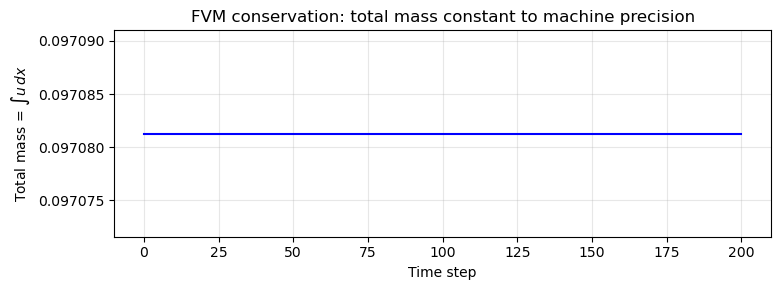

In [3]:
# ── Prove FVM is exactly conservative: total quantity is preserved ────────────
# Solve 1D unsteady advection: du/dt + c*du/dx = 0 with periodic BCs
# Using FVM (upwind flux). Total integral ∫u dx must be constant.

N   = 60
L   = 1.0
dx  = L / N
xc  = np.linspace(dx/2, L-dx/2, N)
c   = 1.0
dt  = 0.5 * dx / c   # CFL = 0.5

u   = np.exp(-((xc - 0.2)**2) / 0.003)   # Gaussian blob

mass_initial = np.sum(u) * dx   # total "mass" = ∫u dx
mass_history = [mass_initial]

for _ in range(200):
    # ── FVM upwind flux at each face ──────────────────────────────────────────
    # c > 0: flux at face i+1/2 = c * u_i (upwind = left cell)
    # Periodic: left-face of cell 0 has flux c * u_{N-1}
    flux = c * u   # upwind flux at each cell's East face

    # ── Conservative update: du/dt = -(F_E - F_W)/Δx ─────────────────────────
    # F_E of cell i = flux[i], F_W of cell i = flux[(i-1) % N]
    u = u - dt/dx * (flux - np.roll(flux, 1))

    mass_history.append(np.sum(u) * dx)

mass_final = mass_history[-1]
print('=== FVM exact conservation proof ===')
print(f'Total mass before: {mass_initial:.12f}')
print(f'Total mass after:  {mass_final:.12f}')
print(f'Change:            {abs(mass_final - mass_initial):.2e}  ← machine precision')
print()
print('Interpretation:')
print('  Every time step, the flux leaving cell i equals the flux entering cell i+1.')
print('  The total telescopes: all internal fluxes cancel. Only boundary fluxes change the total.')
print('  With periodic BCs, even boundary fluxes cancel → total is EXACTLY constant.')

plt.figure(figsize=(8, 3))
plt.plot(mass_history, 'b-', lw=1.5)
plt.xlabel('Time step'); plt.ylabel('Total mass = $\\int u\\,dx$')
plt.title('FVM conservation: total mass constant to machine precision')
plt.ylim([mass_initial * 0.9999, mass_initial * 1.0001])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| FVM concept | Key point |
|-------------|----------|
| Governing principle | Integrate conservation law over each cell — exact |
| Storage | Cell averages $\bar{u}_i$, not point values |
| Flux | One number per face — from reconstruction of cell values |
| Reconstruction | Upwind (1st order, stable) or linear (2nd order, may oscillate) |
| Conservation | Exact by construction — internal fluxes cancel exactly |
| Convergence | 2nd order with linear reconstruction, same as central FDM |
| Why used in CFD | Conservative, handles unstructured meshes, industry standard |

**Critical lesson:** FVM and FDM give identical results on a uniform Cartesian grid with linear reconstruction. The difference only matters for conservation (FVM guarantees it) and for unstructured meshes (FVM handles them, FDM cannot).

---
**Next:** Module 2.3 — Navier-Stokes Equations: every term explained physically, non-dimensionalisation, and why pressure is the hardest part.